In [30]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
import logging

start cross validation for {'lr': 0.01, 'hidden_layers': [8, 4]}
Config : {'lr': 0.01, 'hidden_layers': [8, 4]} | average accuracies : 0.9700
start cross validation for {'lr': 0.001, 'hidden_layers': [16, 8, 4]}
Config : {'lr': 0.001, 'hidden_layers': [16, 8, 4]} | average accuracies : 0.8400
start cross validation for {'lr': 0.01, 'hidden_layers': [32, 16]}
Config : {'lr': 0.01, 'hidden_layers': [32, 16]} | average accuracies : 0.9850
Best config : {'lr': 0.01, 'hidden_layers': [32, 16]} | best scroe : 0.9850000023841858
Training finished, evaluating the final model
Final test accuracy 1.0


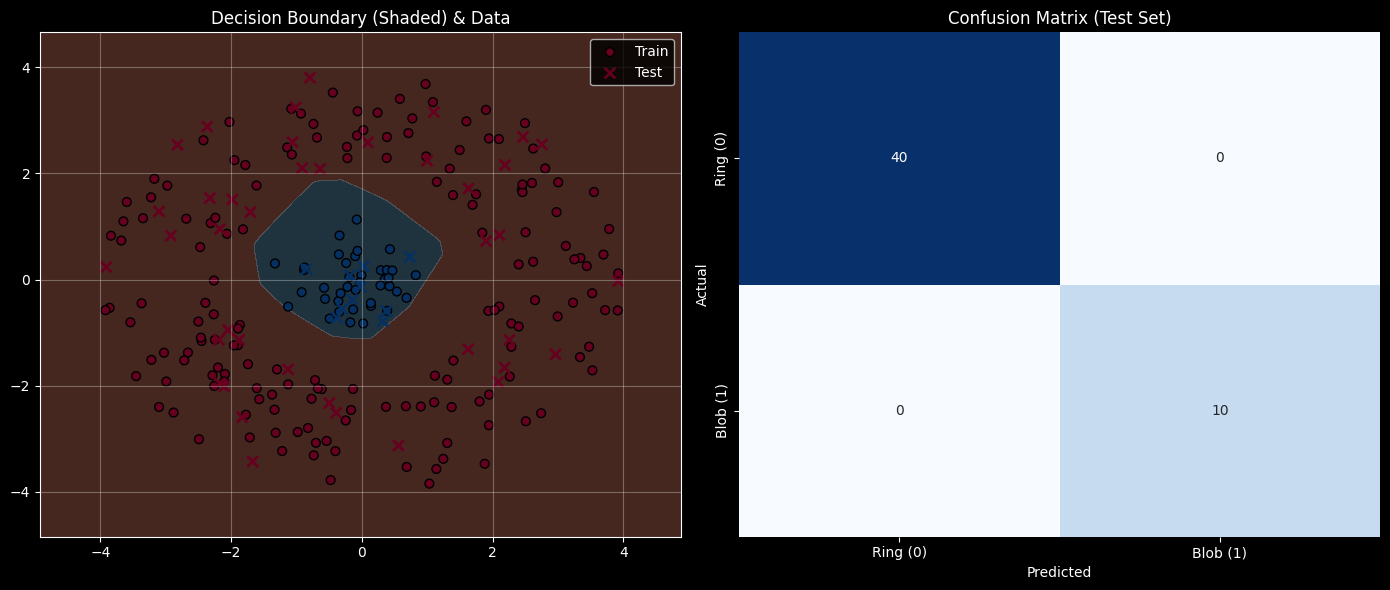

In [ ]:
from sklearn.metrics import confusion_matrix


def generate_data(
    n_class_a=150, n_class_b=50, radius_min=2, radius_max=4, random_seed=0
) -> np.ndarray:
    np.random.seed(random_seed)
    theta = np.random.uniform(low=0, high=2 * np.pi, size=n_class_a)
    r = np.random.uniform(low=radius_min, high=radius_max, size=n_class_a)
    class_a_x = r * np.cos(theta)
    class_a_y = r * np.sin(theta)
    class_b = np.random.normal(loc=0.0, scale=0.5, size=(n_class_b, 2))

    label_a = np.zeros(shape=(n_class_a, 1))
    label_b = np.ones(shape=(n_class_b, 1))
    class_a = np.column_stack((class_a_x, class_a_y))

    classes = np.vstack((class_a, class_b))
    labels = np.vstack((label_a, label_b))
    return classes, labels


# X, Y = generate_data()


def create_model(learning_rate=0.01, hidden_layers=[8, 4]) -> Sequential:
    model = Sequential()
    model.add(tf.keras.Input(shape=(2,)))
    for nodes in hidden_layers:
        model.add(
            Dense(
                nodes,
                activation="relu",
                kernel_initializer="glorot_uniform",
                bias_initializer=tf.keras.initializers.Constant(0.1),
                kernel_regularizer=tf.keras.regularizers.L2(0.01),
            )
        )
    model.add(Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


def run_cross_validation(X, Y, config, n_splits=5):
    fold_accuracies = []
    folds = KFold(n_splits=n_splits, shuffle=True, random_state=0)
    print(f"start cross validation for {config}")
    for i, (training_idx, val_idx) in enumerate(folds.split(X, Y)):
        X_train, X_val = X[training_idx], X[val_idx]
        Y_train, Y_val = Y[training_idx], Y[val_idx]

        model = create_model(config["lr"], config["hidden_layers"])
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.fit_transform(X_val)

        es = EarlyStopping(
            monitor="val_loss", patience=10, restore_best_weights=True, verbose=0
        )
        model.fit(
            X_train_scaled,
            Y_train,
            validation_data=(X_val_scaled, Y_val),
            epochs=100,
            batch_size=32,
            callbacks=[es],
            verbose=0,
        )
        _, acc = model.evaluate(X_val_scaled, Y_val, verbose=0)
        fold_accuracies.append(acc)
    avg_acc = np.mean(fold_accuracies)
    print(f"Config : {config} | average accuracies : {avg_acc:.4f}")
    return avg_acc

def visualize_results(model, scaler, X_train, Y_train, X_test, Y_test):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    ax = axes[0]
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_points_scaled = scaler.transform(grid_points)
    Z = model.predict(grid_points_scaled, verbose=0)
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.3, cmap="RdBu")
    
    scatter = ax.scatter(X_train[:, 0], X_train[:, 1], c=Y_train.ravel(), 
                         cmap="RdBu", edgecolor='k', s=40, label="Train")

    ax.scatter(X_test[:, 0], X_test[:, 1], c=Y_test.ravel(), 
               cmap="RdBu", marker='x', s=60, linewidth=2, label="Test")
    
    ax.set_title("Decision Boundary (Shaded) & Data")
    ax.legend()
    ax.grid(True, alpha=0.3)


    ax = axes[1]
    
    X_test_scaled = scaler.transform(X_test)
    y_pred_prob = model.predict(X_test_scaled, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    cm = confusion_matrix(Y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,  # noqa: F821
                xticklabels=['Ring (0)', 'Blob (1)'],
                yticklabels=['Ring (0)', 'Blob (1)'])
    
    ax.set_title("Confusion Matrix (Test Set)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

def find_best_config(X_train, Y_train):
    configs = [
        {"lr": 0.01, "hidden_layers": [8, 4]},
        {"lr": 0.001, "hidden_layers": [16, 8, 4]},
        {"lr": 0.01, "hidden_layers": [32, 16]},
    ]

    best_score = 0
    best_config = None

    for config in configs:
        avg_acc = run_cross_validation(X_train, Y_train, config)
        if avg_acc > best_score:
            best_score = avg_acc
            best_config = config
    print(f"Best config : {best_config} | best scroe : {best_score}")
    return best_config, best_score


def final_train_and_evaluate():
    X, Y = generate_data(n_class_a=200, n_class_b=50)
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, shuffle=True, test_size=0.2, stratify=Y
    )
    best_config, _ = find_best_config(X_train, Y_train)
    model = create_model(best_config["lr"], best_config["hidden_layers"])
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    model.fit(
        X_train_scaled,
        Y_train,
        epochs=200,
        batch_size=32,
        validation_split=0.1,
        verbose=0,
    )

    print("Training finished, evaluating the final model")
    X_test_scaled = scaler.fit_transform(X_test)
    loss, acc = model.evaluate(X_test_scaled, Y_test, verbose=0)
    print(f"Final test accuracy {acc}")
    visualize_results(model, scaler, X_train, Y_train, X_test, Y_test)

final_train_and_evaluate()